# Frekvensmodell for egen skade

Poisson-GLM for forventet antall egen-skader per eksponeringsår på
kaskoproduktene. Variabler og funksjonsformer velges ved gruppert
kryssvalidering (CV) med en fast seleksjonsregel (§4), og den valgte modellen
kontrolleres med residualdiagnostikk (§7–9). Samme seleksjonsregel som i
severity- og Tweedie-notebookene. Bare utviklingsårene 2022–2023 er brukt;
2024 er ikke lest.

In [1]:
from functools import partial

import pandas as pd
import statsmodels.api as sm
from IPython.display import display

from src_asserts.common_glm_asserts import (
    assert_full_oof_coverage,
    assert_model_definition,
    assert_valid_folds,
)
from src_asserts.frequency_asserts import (
    assert_frequency_frame,
    assert_frequency_spec,
)
from src_asserts.residual_diagnostics_asserts import (
    assert_residual_diagnostics_result,
)
from src_core_glm.glm_core import cross_validate_glm, fit_glm, prepare_design_frame
from src_core_glm.model_data import (
    TRAIN_YEARS,
    add_seat_category,
    build_development_frames,
    to_model_frame,
)
from src_core_glm.model_selection import (
    build_specification,
    can_add,
    evaluate_models_parallel,
    propose_additions,
    propose_geography,
    propose_removals,
    propose_spline_forms,
    run_round,
    run_stepwise,
    select_candidate_stage,
)
from src_core_glm.residual_diagnostics import (
    build_residual_diagnostic_summary,
    cross_validate_residual_catboost,
    plot_residual_diagnostic_overview,
)
from src_core_glm.selection_report import (
    build_forward_selection_table,
    build_top_models_table,
)
from src_core_glm.validation import build_group_folds
from src_frequency.frequency_diagnostics import (
    build_coefficient_table,
    build_glm_summary,
    build_rootogram_table,
    compare_candidate_coefficients,
    plot_oof_residuals_against_fitted,
    plot_oof_residuals_by_continuous_predictor,
    plot_rootogram,
    poisson_deviance_residuals,
)
from src_model_comparison.locked_models import lock_glm
from src_model_comparison.variable_coverage import build_variable_coverage

SEED = 100
N_FOLDS = 5
SE_MULTIPLIER = 1.0  # fjerde seleksjonskrav (§4): snittgevinst > 1 standardfeil
N_JOBS = 8  # parallelle prosesser for kandidat-CV (resultatene er de samme som med 1)

## 1. Datagrunnlag

Vi avgrenser til kaskoproduktene. Manglende verdier håndteres inne i hver
CV-fold: median for tall og `MISSING` for kategorier.

### 1.1 Datarensing

In [2]:
frames = build_development_frames()
development = frames["development"]

# Kolonnene som er tilgjengelige for modellene. Selve modellvalget står i §3.
AVAILABLE_COLUMNS = [
    "policy_type",
    "year",
    "driver_age",
    "log_vehicle_value",
    "performance_hp_per_tonne",
    "fuel_type",
    "circulation_area",
    "municipality_type",
    "payment_frequency",
    "business_type",
    "vehicle_brand_pooled",
    "seats",
]
model_columns = ["insured_id", "total_exposure", "property_claims", *AVAILABLE_COLUMNS]
model_frame = to_model_frame(development, model_columns)
model_frame["claim_frequency"] = (
    model_frame["property_claims"] / model_frame["total_exposure"]
)
add_seat_category(model_frame)  # seter som <5, =5, >5 (som i severity og frekvens)
assert_frequency_frame(model_frame, development)  # sanity-sjekk, kan fjernes

display(frames["cleaning_log"])

,step,affected_rows,result
0,"Kontroll av skjema, kategorikoder og unik poli...",0,Bestått
1,Fjerning av omkringliggende mellomrom i tekstfelt,0,Standardisert
2,Ikke-positiv power_to_weight_ratio satt til ma...,1,Standardisert
3,Manglende total- og ansvarseksponering satt ti...,1,Korrigert
4,Rader slettet eller imputert,0,Ingen


### 1.2 Utvalg

In [3]:
display(
    pd.DataFrame(
        {
            "poliseaar": [len(model_frame)],
            "eksponeringsaar": [model_frame["total_exposure"].sum()],
            "skader": [model_frame["property_claims"].sum()],
            "utviklingsaar": [", ".join(map(str, TRAIN_YEARS))],
        }
    ).round(2)
)

,poliseaar,eksponeringsaar,skader,utviklingsaar
0,55246,37126.01,9989,"2022, 2023"


## 2. Validering

Fem gruppefolder på `insured_id` måler hvor godt modellen generaliserer til
andre forsikrede: samme forsikrede ligger aldri i både trening og validering.

In [4]:
cv_folds = build_group_folds(
    model_frame,
    group_column="insured_id",
    n_splits=N_FOLDS,
    shuffle=True,
    random_state=SEED,
)
assert_valid_folds(cv_folds, model_frame)  # sanity-sjekk, kan fjernes

## 3. Modellspesifikasjon

$$
Y_i = \frac{N_i}{e_i} \sim \operatorname{Poisson}, \qquad
\operatorname{E}[Y_i] = \lambda_i, \qquad
\operatorname{Var}(Y_i) = \frac{\lambda_i}{e_i}, \qquad
\log \lambda_i = \beta_0 + \sum_j f_j(x_{ij}) + \sum_{(j,k)} \gamma_{jk}\, x_{ij} x_{ik}.
$$

$N_i$ er skadeantall, $e_i$ eksponering og $\lambda_i$ skadefrekvens per
eksponeringsår. Responsen er frekvensen $Y_i$ med $e_i$ som vekt (`var_weights`,
ingen offset); det gir samme estimater som Poisson på antall med $\log e_i$ som
offset. $f_j$ er lineær eller en naturlig kubisk spline, og $\gamma_{jk}$ er en
interaksjon.

In [5]:
# Hvilke variabler som er hva. Seleksjonen under leser bare disse listene.
LOCKED = ["policy_type", "year"]  # alltid med, fjernes aldri
CORE = ["log_vehicle_value", "circulation_area", "payment_frequency", "driver_age"]
GEOGRAPHY = "municipality_type"  # testes mot og sammen med circulation_area
ADDITIONAL = [  # tillegg: legges til én om gangen, så lenge de forbedrer modellen
    "performance_hp_per_tonne",
    "fuel_type",
    "business_type",
    "vehicle_brand_pooled",
    "seat_category",
]
INTERACTIONS = [  # testes bare når begge hovedeffektene allerede er med
    ("driver_age", "performance_hp_per_tonne"),
    ("driver_age", "policy_type"),
    ("driver_age", "log_vehicle_value"),
]

# En modell er en liste med termer (kolonne eller interaksjon) og eventuelle splines.
definitions = {"K0": {"terms": [*LOCKED, *CORE], "splines": {}}}

In [6]:
FREQUENCY_SETTINGS = {
    "y": "claim_frequency",
    "family": sm.families.Poisson(link=sm.families.links.Log()),
    "weight": "total_exposure",
    "power": 1,  # Poisson-deviance (Tweedie-power 1)
}


def build_frequency_specification(name, definition):
    """Bygg Poisson-spesifikasjonen (log-link, eksponeringsvekt, ingen offset)."""
    return build_specification(name, definition, model_frame, FREQUENCY_SETTINGS)


assert_frequency_spec(
    build_frequency_specification("K0", definitions["K0"])
)  # kan fjernes

## 4. Sammenligning og valg

Alle trinn bruker den samme firleddsregelen: en kandidat velges bare hvis den har
**lavere pooled OOF-deviance** enn foreldremodellen, er **bedre i minst fire av
fem folder**, har **gyldig fit i alle folder** og har en **snittgevinst over én
standardfeil**. Med $d_k$ = foreldrens minus kandidatens deviance i fold $k$ er
siste krav

$$\bar d > \frac{s_d}{\sqrt{5}}, \qquad \bar d = \tfrac15\sum_k d_k.$$

Kravet er et grovt støyfilter mot små, tilfeldige gevinster, ikke en formell test.

| Trinn | Type | Kandidater |
|---|---|---|
| 4.2–4.3 Funksjonsform | ett valg | alder: spline df 2, 3, 4; bilverdi: spline df 3 |
| 4.4 Geografi | ett valg | `municipality_type` i stedet for, eller i tillegg til, `circulation_area` |
| 4.5 Tillegg | forover-løkke | `ADDITIONAL`, én om gangen til ingen består |
| 4.6 Interaksjoner | forover-løkke | `INTERACTIONS` |
| 4.7 Ablasjon | bakover-løkke | alle termer unntatt `LOCKED` |

Ablasjonen kan ikke fjerne en hovedeffekt så lenge en interaksjon bruker den.

### 4.1 Startmodellen K0

K0 (låste variabler + kjerne, alle lineære) får sin første CV-score.
Poisson-deviance ($p=1$) er fastlagt av familien.

In [7]:
cv_results, specifications = {}, {}


def evaluate_model(name):
    """Bygg spesifikasjonen og kjør CV for én modelldefinisjon."""
    assert_model_definition(definitions[name], LOCKED)  # sanity-sjekk, kan fjernes
    specification = build_frequency_specification(name, definitions[name])
    return specification, cross_validate_glm(specification, model_frame, cv_folds)


def evaluate_models(names):
    """Kjør CV for flere modelldefinisjoner parallelt (én prosess per kandidat)."""
    evaluate_models_parallel(evaluate_model, specifications, cv_results, N_JOBS, names)


# Firleddsregelen med Poisson-deviance; kalles som select_stage(foreldre, kandidatnavn).
select_stage = partial(
    select_candidate_stage,
    cv_results,
    response=model_frame["claim_frequency"],
    sample_weight=model_frame["total_exposure"],
    power=FREQUENCY_SETTINGS["power"],
    se_multiplier=SE_MULTIPLIER,
)

evaluate_models(["K0"])

### 4.2 Funksjonsform: alder

Lineær alder (K0) utfordres av naturlig kubisk spline med 2, 3 og 4
frihetsgrader; bare én form kan velges.

In [8]:
core = definitions["K0"]
age_alternatives = propose_spline_forms(core, "driver_age", "alder", (2, 3, 4))
age_model, age_table = run_round(
    "K0", age_alternatives, definitions, evaluate_models, select_stage
)
display(age_table.round(4))
print(f"Valgt etter aldersform: {age_model}")

,oof_deviance,lavere_oof,bedre_4_av_5,gyldig_i_alle_folder,snitt_gevinst,se_gevinst,gevinst_over_se,cv_feil,endring,valgt
modell,,,,,,,,,,
K0+alder_df2,1.1271,True,True,True,0.0013,0.0003,True,,+alder_df2,False
K0+alder_df3,1.1270,True,True,True,0.0015,0.0005,True,,+alder_df3,False
K0+alder_df4,1.1269,True,True,True,0.0015,0.0005,True,,+alder_df4,True


Valgt etter aldersform: K0+alder_df4


### 4.3 Funksjonsform: bilverdi

`log_vehicle_value` utfordres av en spline med 3 frihetsgrader.

In [9]:
current = definitions[age_model]
value_alternatives = propose_spline_forms(
    current, "log_vehicle_value", "bilverdi", (3,)
)
value_model, value_table = run_round(
    age_model, value_alternatives, definitions, evaluate_models, select_stage
)
display(value_table.round(4))
print(f"Valgt etter bilverdi: {value_model}")

,oof_deviance,lavere_oof,bedre_4_av_5,gyldig_i_alle_folder,snitt_gevinst,se_gevinst,gevinst_over_se,cv_feil,endring,valgt
modell,,,,,,,,,,
K0+alder_df4+bilverdi_df3,1.1274,False,False,True,-0.0005,0.0002,False,,+bilverdi_df3,False


Valgt etter bilverdi: K0+alder_df4


### 4.4 Geografi

`municipality_type` testes enten *i stedet for* eller *i tillegg til*
`circulation_area`; bare ett alternativ kan velges.

In [10]:
current = definitions[value_model]
geography_alternatives = propose_geography(current, GEOGRAPHY, "circulation_area")
geography_model, geography_table = run_round(
    value_model, geography_alternatives, definitions, evaluate_models, select_stage
)
display(geography_table.round(4))
print(f"Valgt etter geografi: {geography_model}")

,oof_deviance,lavere_oof,bedre_4_av_5,gyldig_i_alle_folder,snitt_gevinst,se_gevinst,gevinst_over_se,cv_feil,endring,valgt
modell,,,,,,,,,,
K0+alder_df4+municipality_type,1.1270,False,False,True,-0.0002,0.0001,False,,+municipality_type,False
K0+alder_df4_bytt_til_municipality_type,1.1285,False,False,True,-0.0016,0.0006,False,,_bytt_til_municipality_type,False


Valgt etter geografi: K0+alder_df4


### 4.5 Tillegg

Forover-seleksjon: beste tillegg som består regelen legges til, og de
gjenstående testes på nytt mot den nye modellen, til ingen består.

In [11]:
additions_model, additions_table = run_stepwise(
    geography_model,
    propose_additions(ADDITIONAL),
    definitions,
    evaluate_models,
    select_stage,
)
display(additions_table.round(4))
print(f"Valgt etter tillegg: {additions_model}")

,oof_deviance,lavere_oof,bedre_4_av_5,gyldig_i_alle_folder,snitt_gevinst,se_gevinst,gevinst_over_se,cv_feil,endring,valgt,runde
modell,,,,,,,,,,,
K0+alder_df4+performance_hp_per_tonne,1.1271,False,False,True,-0.0002,0.0001,False,,+performance_hp_per_tonne,False,1
K0+alder_df4+fuel_type,1.1262,True,False,True,0.0007,0.0006,True,,+fuel_type,False,1
K0+alder_df4+business_type,1.1222,True,True,True,0.0046,0.0008,True,,+business_type,True,1
K0+alder_df4+vehicle_brand_pooled,1.1264,True,False,True,0.0005,0.0005,False,,+vehicle_brand_pooled,False,1
K0+alder_df4+seat_category,1.1270,False,False,True,-0.0001,0.0002,False,,+seat_category,False,1
K0+alder_df4+business_type+performance_hp_per_tonne,1.1224,False,False,True,-0.0002,0.0001,False,,+performance_hp_per_tonne,False,2
K0+alder_df4+business_type+fuel_type,1.1216,True,False,True,0.0006,0.0006,True,,+fuel_type,False,2
K0+alder_df4+business_type+vehicle_brand_pooled,1.1218,True,False,True,0.0004,0.0005,False,,+vehicle_brand_pooled,False,2
K0+alder_df4+business_type+seat_category,1.1224,False,False,True,-0.0001,0.0002,False,,+seat_category,False,2


Valgt etter tillegg: K0+alder_df4+business_type


### 4.6 Interaksjoner

Samme forover-løkke. En interaksjon testes bare når begge hovedeffektene er i
modellen.

In [12]:
interaction_model, interaction_table = run_stepwise(
    additions_model,
    propose_additions(INTERACTIONS),
    definitions,
    evaluate_models,
    select_stage,
)
display(interaction_table.round(4))
final_definition = definitions[interaction_model]
not_tested = [
    term
    for term in INTERACTIONS
    if term not in final_definition["terms"] and not can_add(final_definition, term)
]
print(f"Valgt etter interaksjoner: {interaction_model}")
print(f"Ikke testet (mangler hovedeffekt): {not_tested or 'ingen'}")

/workspaces/MotorForsikring/.venv/lib/python3.12/site-packages/statsmodels/genmod/generalized_linear_model.py:1486: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  wls_results = wls_model.fit(method=wls_method2)


/workspaces/MotorForsikring/.venv/lib/python3.12/site-packages/statsmodels/genmod/generalized_linear_model.py:1486: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  wls_results = wls_model.fit(method=wls_method2)


/workspaces/MotorForsikring/.venv/lib/python3.12/site-packages/statsmodels/genmod/generalized_linear_model.py:1486: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  wls_results = wls_model.fit(method=wls_method2)


/workspaces/MotorForsikring/.venv/lib/python3.12/site-packages/statsmodels/genmod/generalized_linear_model.py:1486: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  wls_results = wls_model.fit(method=wls_method2)


/workspaces/MotorForsikring/.venv/lib/python3.12/site-packages/statsmodels/genmod/generalized_linear_model.py:1486: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  wls_results = wls_model.fit(method=wls_method2)


,oof_deviance,lavere_oof,bedre_4_av_5,gyldig_i_alle_folder,snitt_gevinst,se_gevinst,gevinst_over_se,cv_feil,endring,valgt,runde
modell,,,,,,,,,,,
K0+alder_df4+business_type+driver_age*policy_type,NaN,False,True,False,0.0003,0.0001,True,gruppe_1: rangsvikt (13 av 14 kolonner); grupp...,+driver_age*policy_type,False,1
K0+alder_df4+business_type+driver_age*log_vehicle_value,1.1223,False,False,True,-0.0001,0.0003,False,,+driver_age*log_vehicle_value,False,1


Valgt etter interaksjoner: K0+alder_df4+business_type
Ikke testet (mangler hovedeffekt): [('driver_age', 'performance_hp_per_tonne')]


### 4.7 Ablasjon

Bakover-løkke: én term (unntatt `LOCKED`) fjernes om gangen, og fjerningen
beholdes bare når den oppfyller den samme firleddsregelen.

In [13]:
final_model, ablation_table = run_stepwise(
    interaction_model,
    propose_removals(set(LOCKED)),
    definitions,
    evaluate_models,
    select_stage,
)
display(ablation_table.round(4))
print(f"Valgt etter ablasjon: {final_model}")

,oof_deviance,lavere_oof,bedre_4_av_5,gyldig_i_alle_folder,snitt_gevinst,se_gevinst,gevinst_over_se,cv_feil,endring,valgt,runde
modell,,,,,,,,,,,
K0+alder_df4+business_type-log_vehicle_value,1.1278,False,False,True,-0.0056,0.0013,False,,-log_vehicle_value,False,1
K0+alder_df4+business_type-circulation_area,1.1236,False,False,True,-0.0014,0.0007,False,,-circulation_area,False,1
K0+alder_df4+business_type-payment_frequency,1.1239,False,False,True,-0.0017,0.0011,False,,-payment_frequency,False,1
K0+alder_df4+business_type-driver_age,1.1242,False,False,True,-0.0019,0.0003,False,,-driver_age,False,1
K0+alder_df4+business_type-business_type,1.1269,False,False,True,-0.0046,0.0008,False,,-business_type,False,1


Valgt etter ablasjon: K0+alder_df4+business_type


### 4.8 Hva tilfører verdi?

Én rad per valgt steg (§4.2–4.6). `oof_deviance` er pooled OOF etter steget,
`snitt_gevinst` og `se_gevinst` er snitt og standardfeil av fold-gevinstene mot
foreldremodellen, og `gevinst_i_se` er forholdet. Rundt 1 er marginalt (den
beste av mange kandidater havner ofte på 1–1,5 SE uten ekte signal); tydelig
verdi krever vesentlig mer.

In [14]:
display(
    build_forward_selection_table(
        [age_table, value_table, geography_table, additions_table, interaction_table]
    ).round(4)
)
assert_model_definition(definitions[final_model], LOCKED)  # sanity-sjekk, kan fjernes
print("Valgt frekvensmodell:", definitions[final_model])

,endring,oof_deviance,snitt_gevinst,se_gevinst,gevinst_i_se
steg,,,,,
1,+alder_df4,1.1269,0.0015,0.0005,3.0137
2,+business_type,1.1222,0.0046,0.0008,5.9242


Valgt frekvensmodell: {'terms': ['policy_type', 'year', 'log_vehicle_value', 'circulation_area', 'payment_frequency', 'driver_age', 'business_type'], 'splines': {'driver_age': 4}}


### 4.9 Konkurrerende modeller

De tre evaluerte modellene med lavest pooled OOF-deviance. `endring` er hva som
skiller dem fra den valgte modellen, `parametere` inkluderer konstantledd, og
`delta_mot_valgt` er OOF-deviance minus den valgtes (negativ = lavere). En
enklere modell som er praktisk talt like god foretrekkes; en mer kompleks bare
hvis forskjellen er tydelig over støyen (se §4.8).

In [15]:
top_models = build_top_models_table(
    cv_results,
    definitions,
    final_model,
    model_frame["claim_frequency"],
    model_frame["total_exposure"],
    FREQUENCY_SETTINGS["power"],
)
with pd.option_context("display.max_colwidth", None):
    display(top_models.reset_index(drop=True).round(4))

,endring,variabler,parametere,oof_deviance,delta_mot_valgt
0,+ fuel_type,"policy_type, year, log_vehicle_value, circulation_area, payment_frequency, driver_age (spline df 4), business_type, fuel_type",14,1.1216,-0.0006
1,+ vehicle_brand_pooled,"policy_type, year, log_vehicle_value, circulation_area, payment_frequency, driver_age (spline df 4), business_type, vehicle_brand_pooled",29,1.1218,-0.0004
2,valgt modell,"policy_type, year, log_vehicle_value, circulation_area, payment_frequency, driver_age (spline df 4), business_type",12,1.1222,0.0000


### 4.10 Endelig modell

Frekvensen $Y_i=N_i/e_i$ (skader per eksponeringsår) er Poisson med
vekt $e_i$ og log-link:

$$
\log\lambda_i=\beta_0
+\beta_{\mathrm{pol}}[\mathrm{policy}_i]
+\beta_{\mathrm{yr}}[\mathrm{year}_i]
+\beta_{\mathrm{area}}[\mathrm{area}_i]
+\beta_{\mathrm{pay}}[\mathrm{pay}_i]
+\beta_{\mathrm{bus}}[\mathrm{bus}_i]
+\gamma\,\ell_i
+f(\mathrm{age}_i).
$$

$[\cdot]$ er nivåeffekten til kategorien (0 for referansenivået), $\ell_i$ er
`log_vehicle_value` (lineær) og $f$ er en naturlig kubisk spline i `driver_age`
med 4 frihetsgrader (sentrert). Referansenivåer: `policy_type` = COMP_E, `year` =
2023, `circulation_area` = U, `payment_frequency` = A, `business_type` = NB.
Parametere: $1+1+1+1+2+1+1+4=12$. Ingen interaksjoner er valgt.

In [16]:
final_definition = definitions[final_model]
final_specification = specifications[final_model]
assert final_definition["terms"] == [
    "policy_type",
    "year",
    "log_vehicle_value",
    "circulation_area",
    "payment_frequency",
    "driver_age",
    "business_type",
]
assert final_definition["splines"] == {"driver_age": 4}
assert final_specification["base_levels"] == {
    "policy_type": "COMP_E",
    "year": 2023,
    "circulation_area": "U",
    "payment_frequency": "A",
    "business_type": "NB",
}

### 4.11 Estimering på alle utviklingsdata

Den valgte modellen estimeres på alle utviklingsdata (2022–2023) med
cluster-robuste standardfeil på `insured_id`. Deviance og $D^2$ er in-sample.

In [17]:
final_design = prepare_design_frame(
    model_frame, model_frame, final_specification["required_columns"]
)
final_fit = fit_glm(
    final_specification, final_design, cluster_groups=final_design["insured_id"]
)
assert len(final_fit.params) == 12  # samme som parameterantallet i §4.10
final_summary = build_glm_summary(final_specification, final_fit, final_design)
with pd.option_context("display.max_colwidth", None):
    display(final_summary.to_frame().T.round(4))

,formel,familie,rader,parametere,deviance,d2,balanse
K0+alder_df4+business_type,"claim_frequency ~ C(policy_type, Treatment('COMP_E')) + C(year, Treatment(2023)) + log_vehicle_value + C(circulation_area, Treatment('U')) + C(payment_frequency, Treatment('A')) + cr(driver_age, df=4, constraints='center') + C(business_type, Treatment('NB'))",Poisson,55246,12,1.120536,0.09872,1.0


## 5. Koeffisienter

Koeffisientene er log-relativiteter i dette datasettet, ikke kausale effekter.
`relativitet` er $e^{\text{koeffisient}}$.

In [18]:
display(build_coefficient_table(final_fit).round(3))

,koeffisient,standardfeil,z,p_verdi,ki_95_lav,ki_95_høy,relativitet
Intercept,-5.656,0.417,-13.569,0.000,-6.472,-4.839,0.003
"C(policy_type, Treatment('COMP_E'))[T.COMP_N]",1.299,0.033,39.220,0.000,1.234,1.364,3.666
"C(year, Treatment(2023))[T.2022]",-0.083,0.037,-2.276,0.023,-0.155,-0.012,0.920
"C(circulation_area, Treatment('U'))[T.R]",-0.162,0.034,-4.817,0.000,-0.228,-0.096,0.851
"C(payment_frequency, Treatment('A'))[T.Q]",0.361,0.063,5.702,0.000,0.237,0.485,1.434
"C(payment_frequency, Treatment('A'))[T.S]",0.095,0.050,1.921,0.055,-0.002,0.193,1.100
"C(business_type, Treatment('NB'))[T.P]",0.305,0.036,8.502,0.000,0.235,0.376,1.357
log_vehicle_value,0.378,0.040,9.417,0.000,0.300,0.457,1.460
"cr(driver_age, df=4, constraints='center')[0]",0.388,0.122,3.191,0.001,0.150,0.627,1.475
"cr(driver_age, df=4, constraints='center')[1]",0.452,0.152,2.982,0.003,0.155,0.749,1.572


## 6. Stabilitet i koeffisientene

Den valgte modellen sammenlignet med de to nærmeste konkurrentene i §4.9. Bare
koeffisienter i den valgte modellen vises. En liten endring tyder på at
estimatet er robust mot alternative spesifikasjoner; det er ikke et mål på
statistisk usikkerhet.

In [19]:
competitors = [name for name in top_models.index if name != final_model][:2]
candidate_fits = {}
for name in [final_model, *competitors]:
    label = "valgt" if name == final_model else top_models.loc[name, "endring"]
    design = prepare_design_frame(
        model_frame, model_frame, specifications[name]["required_columns"]
    )
    candidate_fits[label] = fit_glm(specifications[name], design)
display(compare_candidate_coefficients(candidate_fits, "valgt").round(3))

,valgt,+ fuel_type,endring_fra_valgt_+ fuel_type,+ vehicle_brand_pooled,endring_fra_valgt_+ vehicle_brand_pooled
Intercept,-5.656,-5.129,0.527,-5.031,0.624
"C(policy_type, Treatment('COMP_E'))[T.COMP_N]",1.299,1.297,-0.002,1.297,-0.002
"C(year, Treatment(2023))[T.2022]",-0.083,-0.083,-0.000,-0.084,-0.001
"C(circulation_area, Treatment('U'))[T.R]",-0.162,-0.171,-0.009,-0.159,0.003
"C(payment_frequency, Treatment('A'))[T.Q]",0.361,0.362,0.002,0.368,0.007
"C(payment_frequency, Treatment('A'))[T.S]",0.095,0.095,-0.001,0.093,-0.002
"C(business_type, Treatment('NB'))[T.P]",0.305,0.304,-0.001,0.303,-0.002
log_vehicle_value,0.378,0.331,-0.047,0.319,-0.060
"cr(driver_age, df=4, constraints='center')[0]",0.388,0.375,-0.013,0.356,-0.033
"cr(driver_age, df=4, constraints='center')[1]",0.452,0.453,0.001,0.425,-0.028


## 7. CatBoost-diagnostikk av residualstruktur

Finnes det struktur i middelverdien som den valgte GLM-en ikke fanger? CatBoost
er bare en diagnose og velger aldri GLM-variabler.

$$
z_i=\frac{y_i}{\hat\mu_{i,\mathrm{inner\ OOF}}},
\qquad
a_i=w_i\,\hat\mu_{i,\mathrm{inner\ OOF}}^{\,2-p},
\qquad
\hat\mu_i^*=\hat\mu_{i,\mathrm{GLM}}\,\hat h(x_i).
$$

$z_i$ er observert relativt til GLM-prediksjonen, $a_i$ er radens vekt (her
$p=1$) og $\hat h(x)$ er CatBoosts korreksjonsfaktor lært med Poisson-loss.
Indre CV (fem nye `insured_id`-folder i hver ytre treningsdel) lager $z_i$, så
CatBoost aldri trener på prediksjoner fra en GLM som har sett raden. Ytre CV
måler gevinsten på forsikrede CatBoost ikke har sett. Dybde 1 er additiv,
dybde 3 kan også fange interaksjoner.

In [20]:
residual_diagnostics = cross_validate_residual_catboost(
    final_specification,
    model_frame,
    cv_folds,
    final_specification["required_columns"],
    categorical_columns=tuple(final_specification["base_levels"]),
    blocked_feature_columns=("property_claims",),  # rå skadeantall er responsen
    seed=SEED,
)
assert_residual_diagnostics_result(
    residual_diagnostics, model_frame, cv_folds
)  # kan fjernes

### 7.1 Finnes det residualstruktur?

GLM-en mot en konstant korreksjon og to CatBoost-dybder, på alle OOF-rader.
`delta_*` er reduksjon i deviance (positivt er bedre), `better_than_*_folds`
teller ytre folder med gevinst, og `oof_ae` er faktisk delt på predikert skade.

,benchmark,pooled_oof_deviance,delta_vs_glm,relative_gain_vs_glm,delta_vs_constant,delta_vs_depth_1,better_than_glm_folds,better_than_constant_folds,better_than_depth_1_folds,oof_ae,valid
0,glm,1.1222,0.0000,0.0000,-0.0000,NaN,0,2,NaN,1.0003,True
1,constant,1.1222,0.0000,0.0000,0.0000,NaN,3,0,NaN,1.0004,True
2,catboost_depth_1,1.1227,-0.0004,-0.0004,-0.0004,NaN,0,0,NaN,1.0007,True
3,catboost_depth_3,1.1219,0.0003,0.0003,0.0003,0.0008,3,3,4.0,1.0042,True


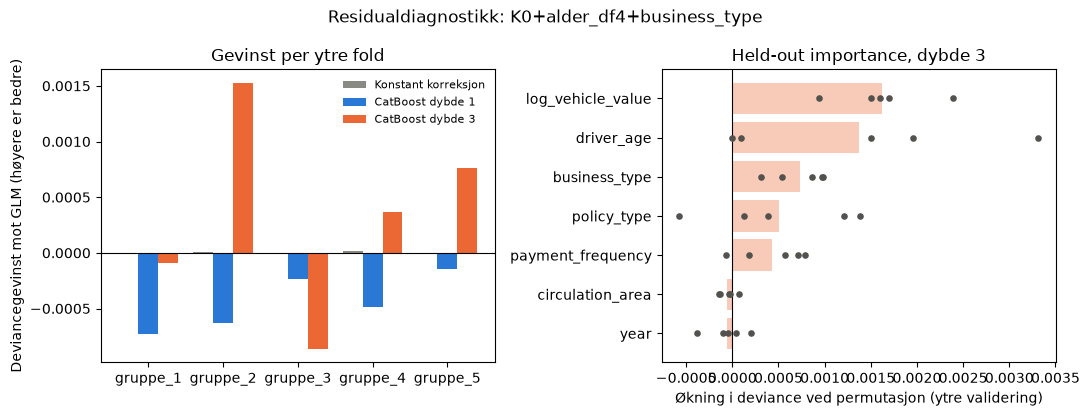

In [21]:
display(build_residual_diagnostic_summary(residual_diagnostics).round(4))
residual_overview_figure = plot_residual_diagnostic_overview(residual_diagnostics)

## 8. OOF-diagnostikk av Poisson-GLM-en

Residualene bygger på prediksjoner fra folden der poliseåret ikke inngikk i
tilpasningen. LOWESS-kurvene er visuelle hjelpemidler, ikke hypotesetester.

### 8.1 Mot predikert frekvens

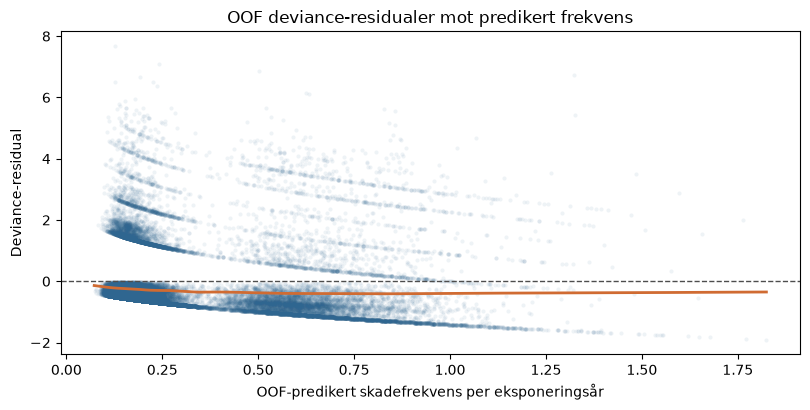

In [22]:
oof_frequency = cv_results[final_model]["oof"]
assert_full_oof_coverage(
    oof_frequency, model_frame.index, "frekvens-OOF"
)  # kan fjernes
oof_expected_claims = oof_frequency * model_frame["total_exposure"]
oof_residuals = poisson_deviance_residuals(
    model_frame["property_claims"], oof_expected_claims
)
oof_fitted_figure = plot_oof_residuals_against_fitted(oof_frequency, oof_residuals)

### 8.2 Mot kontinuerlige prediktorer

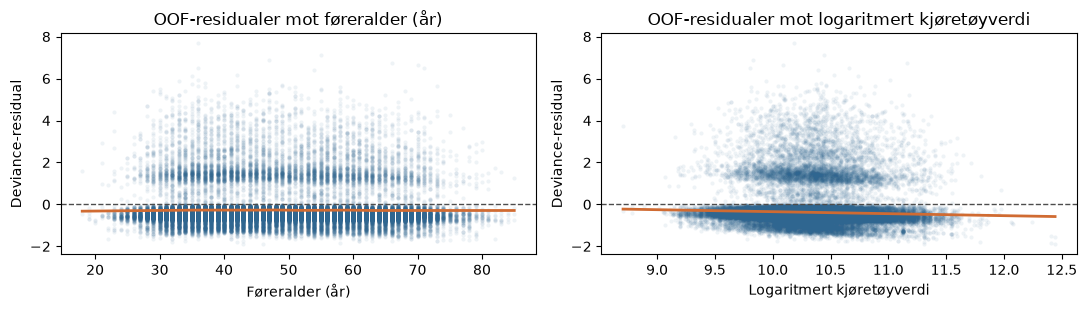

In [23]:
continuous_predictors = [
    predictor
    for predictor in ["driver_age", "log_vehicle_value", "performance_hp_per_tonne"]
    if predictor in final_specification["required_columns"]
]
oof_predictor_figure = plot_oof_residuals_by_continuous_predictor(
    model_frame, continuous_predictors, oof_residuals
)

## 9. OOF-rootogram

Observert skadeantall (hengende søyler) mot summen av de OOF-predikerte
Poisson-sannsynlighetene. Søyler som ikke treffer nullinjen viser hvor
fordelingen ikke passer.

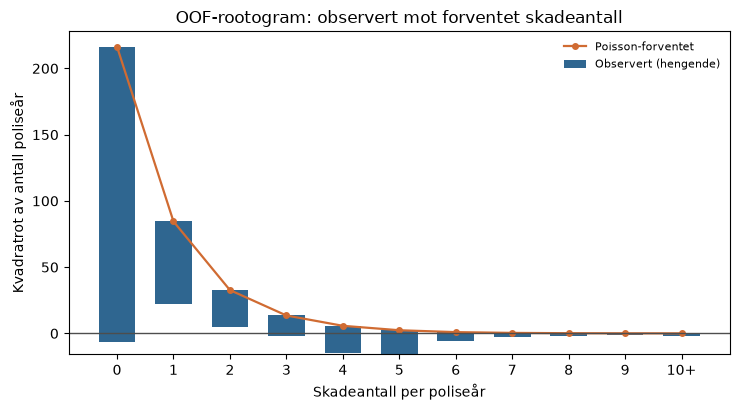

In [24]:
rootogram_table = build_rootogram_table(
    model_frame["property_claims"], oof_expected_claims
)
rootogram_figure = plot_rootogram(rootogram_table)

## 10. Variabelsjekk

Alle tilgjengelige variabler skal enten være testet i kandidatregisteret eller
være utelatt med begrunnelse. Kontrollen feiler ellers.

In [25]:
tested_terms = [*LOCKED, *CORE, GEOGRAPHY, *ADDITIONAL]  # kandidatregisteret
variable_coverage = build_variable_coverage(
    development,
    AVAILABLE_COLUMNS,
    tested_terms,
    final_specification["required_columns"],
)
display(variable_coverage)

,variabel,status,begrunnelse
0,year,i endelig modell,
1,policy_type,i endelig modell,
2,policy_status,utelatt,ukjent om status er kjent ved periodestart
3,business_type,i endelig modell,
4,payment_frequency,i endelig modell,
5,bonus_score,utelatt,tidspunkt for fastsettelse uavklart (lekkasjer...
6,driver_age,i endelig modell,
7,vehicle_age,utelatt,uklar betydning i kildedokumentasjonen
8,age_driving_licence,utelatt,rå verdi; erstattet av utledet erfaring
9,fuel_type,"testet, ikke valgt",


## 11. Låst modell

Den endelige modellen er allerede estimert på alle utviklingsdata (§4.11). Den
lagres i `models/frequency.joblib`, lastes på nytt og kontrolleres mot
notebookens egne prediksjoner.

In [26]:
display(
    lock_glm("frequency", final_specification, final_fit, final_design, development)
)

,modell,fil,størrelse_MB,rader_kontrollert,snitt_prediksjon
0,frequency,models/frequency.joblib,36.87,36254,0.274187


## Begrensninger

- **Optimistisk utviklingsscore.** Samme fem folder brukes til å sammenligne
  mange kandidater og til CatBoost-diagnostikken, så OOF-deviansen er ikke en
  uavhengig evaluering.
- **Få skader.** Datagrunnlaget er 9 989 skader på 55 246 poliseår (37 126
  eksponeringsår). Forskjellene mellom konkurrerende modeller er små
  (`delta_mot_valgt` −0,0006 og −0,0004 for `+ fuel_type` og
  `+ vehicle_brand_pooled`, som ikke besto regelen), og fravær av gevinst i §7
  er ikke bevis for fravær av struktur.
- **Årseffekt.** `year` er en låst kategorisk term, og 2024 finnes ikke i
  treningsdata; 2024 skåres derfor med 2023-nivået (ingen trend-ekstrapolering,
  årsdrift blir liggende i porteføljebalansen).
- **Klipping.** Numeriske prediktorer klippes til treningsområdet ved skåring
  (GLM: se `src_model_comparison/locked_models.py`; CatBoost: trær er flate
  utenfor treningsområdet).
- **Antakelser.** Poisson-varians og log-additive effekter; overspredning
  kontrolleres bare visuelt (§9), og standardfeilene er cluster-robuste på
  `insured_id`. Koeffisientene er assosiasjoner, ikke kausale effekter.
- **Interaksjoner.** `driver_age × policy_type` ga rangsvikt i noen folder og er
  ikke reelt vurdert, og `driver_age × performance_hp_per_tonne` ble ikke testet
  fordi ytelse ikke er i modellen.